# Modelo baseline — AI4I 2020

En este notebook se construirá un modelo baseline para la predicción de fallas de máquinas utilizando el dataset AI4I 2020.

El objetivo es establecer un punto de referencia inicial que permita comparar posteriormente el desempeño de modelos más avanzados, como XGBoost.

Debido al desbalance de la variable objetivo `Machine failure`, la evaluación considerará principalmente precision, recall, F1-score y PR-AUC, además de accuracy como métrica complementaria.

In [1]:
%pip install -q ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

import pandas as pd

## 1. Carga del dataset

Se carga el dataset AI4I 2020 desde el repositorio UCI Machine Learning Repository para preparar los datos que serán utilizados en el modelo baseline.

In [3]:
dataset = fetch_ucirepo(id=601)

df = dataset.data.original

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 10000
Columnas: 14


,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Selección de variables

A partir del análisis exploratorio previo, se seleccionan las variables que serán utilizadas como predictores.

Se excluyen `UID` y `Product ID` por ser identificadores, así como `TWF`, `HDF`, `PWF`, `OSF` y `RNF` para evitar fuga de información respecto de la variable objetivo.

In [4]:
features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

X.head()

Dimensiones de X: (10000, 6)
Dimensiones de y: (10000,)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 3. División de los datos

El conjunto de datos se divide en entrenamiento y prueba. Se utiliza una división estratificada para conservar aproximadamente la misma proporción de máquinas con y sin falla en ambos conjuntos.

El 80 % de los registros se utilizará para entrenamiento y el 20 % restante para evaluación.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribución prueba:")
print(y_test.value_counts(normalize=True).round(4))

Entrenamiento: (8000, 6)
Prueba: (2000, 6)

Distribución entrenamiento:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Distribución prueba:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


## 4. Preprocesamiento de variables

La variable `Type` es categórica y contiene las categorías `L`, `M` y `H`. Para que pueda ser utilizada por el modelo, se transformará mediante One-Hot Encoding.

Las variables numéricas se conservarán sin transformación en esta primera versión del modelo baseline.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Type"]

numeric_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Type'])])

## 5. Construcción del modelo baseline

Se utilizará una regresión logística como modelo baseline de clasificación.

El preprocesamiento y el modelo se integrarán en un único pipeline. De esta manera, la transformación de la variable categórica `Type` y el entrenamiento del modelo se ejecutarán como parte del mismo flujo.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 6. Entrenamiento del modelo baseline

El pipeline se entrena utilizando únicamente el conjunto de entrenamiento. Durante este proceso se aplica el preprocesamiento definido previamente y posteriormente se ajusta el modelo de regresión logística.

In [8]:
baseline_model.fit(X_train, y_train)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


## 7. Evaluación del modelo baseline

El modelo entrenado se evalúa utilizando el conjunto de prueba, que no fue utilizado durante el entrenamiento.

Se calculan accuracy, precision, recall, F1-score y PR-AUC. Debido al desbalance de la variable objetivo, se prestará especial atención a precision, recall, F1-score y PR-AUC.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

Accuracy:  0.9685
Precision: 0.6667
Recall:    0.1471
F1-score:  0.2410
PR-AUC:    0.4335


## 8. Matriz de confusión

Se utiliza una matriz de confusión para analizar la cantidad de predicciones correctas e incorrectas realizadas por el modelo, prestando especial atención a las fallas reales que no fueron detectadas.

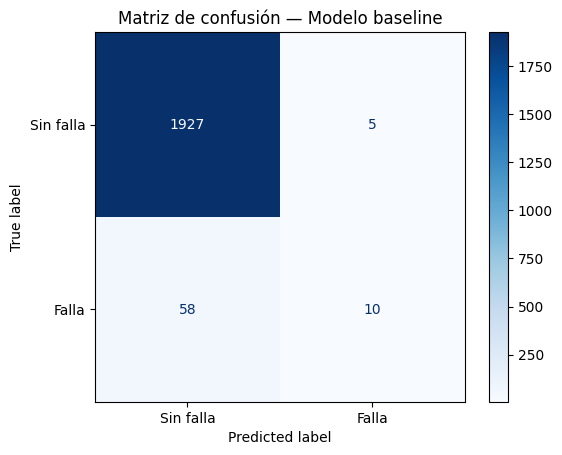

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin falla", "Falla"],
    cmap="Blues"
)

plt.title("Matriz de confusión — Modelo baseline")
plt.show()

## 9. Conclusiones del modelo baseline

El modelo baseline de regresión logística obtuvo un accuracy de 0.9685, precision de 0.6667, recall de 0.1471, F1-score de 0.2410 y PR-AUC de 0.4335.

Aunque el accuracy es elevado, la matriz de confusión muestra que el modelo detectó únicamente 10 de las 68 fallas reales presentes en el conjunto de prueba, mientras que 58 fallas fueron clasificadas incorrectamente como máquinas sin falla.

Estos resultados evidencian que el accuracy por sí solo no representa adecuadamente el desempeño del modelo debido al desbalance de clases. El bajo recall indica una capacidad limitada para identificar máquinas que realmente presentan una falla.

Este modelo se utilizará como punto de referencia para comparar posteriormente el desempeño de modelos más avanzados, especialmente XGBoost.